# LOGO fold pipeline — leave-one-use-case-out, on the generalized pipeline architecture

**Author:** SF — **Branch:** `foldingstrategiesv2` — **Scope:** the LOGO strategy from
`sf_logo_fold_strategy.ipynb`, rebuilt on the same config-driven, `scikit-learn` `Pipeline`
architecture as `sf_generalized_fold_pipeline.ipynb`. Same `CONFIG` shape, same
`scripts/fold_pipeline_utils.py` helpers, same "ready for a differently-shaped engineered
dataset" goal — the only thing that's different from that notebook is *what defines the
outer split*: a whole use case here, instead of a random grouped/stratified slice of rows.

## Why this notebook exists alongside `sf_generalized_fold_pipeline.ipynb`

That notebook answers "how well does a LogisticRegression do on more data from research
questions it has already seen" — useful for iterating on features/preprocessing, but it
never tests the scenario this product actually needs to survive: a genuinely new research
question, with zero training rows, on day one. This notebook is that test, restated on top
of the same pipeline discipline (config-driven columns, split-then-fit, a single
`scikit-learn` `Pipeline` object per fold) so both notebooks stay consistent with each
other as the upstream feature set changes, instead of the LOGO logic drifting out of sync
with whatever `sf_generalized_fold_pipeline.ipynb` learns.

**Tested today against `papers_combined.parquet`** — §0 flags the one stand-in feature the
real engineered dataset will already provide; §6 is the checklist for swapping it in.


In [1]:
import sys
from pathlib import Path

SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold

from fold_pipeline_utils import (
    bootstrap_auc_ci,
    build_pipeline,
    classification_metrics,
    prepare_dataset,
    ranking_metrics,
    validate_schema,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## CONFIG — identical shape to `sf_generalized_fold_pipeline.ipynb`'s

`use_case_col` now does double duty: it's still used for the (informational) leakage check
in §2, but it now also drives the **outer split itself** — see §3. `n_splits_outer` is
unused here (the outer split is "one rotation per unique use case," not a fold count); kept
in `CONFIG` anyway so both pipeline notebooks' configs stay the same shape.


In [2]:
CONFIG = {
    "data_path": "../../data/processed/papers_combined.parquet",
    # target
    "target_col": "triage_label",
    "positive_label": "positive",
    "negative_labels": ["negative"],  # rows outside positive_label/negative_labels are dropped (e.g. this repo's `pass`)
    # columns used by the split/leakage logic, not as model features
    "use_case_col": "use_case_key",     # drives the outer LOGO rotation - see §3
    "group_col": "first_author",        # derived from group_source_col below if not already present
    "group_source_col": "authors",
    "title_col": "title",                # for the duplicate-row leakage check in §2
    # model features - extend these two lists as feature engineering lands new columns;
    # nothing else in this notebook needs to change
    "embedding_col": "embedding",        # expanded into emb_0..emb_{d-1} by prepare_dataset, dimensionality inferred at runtime
    "numeric_feature_cols": ["citation_velocity"],
    "categorical_feature_cols": [],
    # inner-loop split size only - the outer split is one rotation per use case (§3), not a fold count
    "n_splits_outer": 5,   # unused here, kept for config-shape parity with sf_generalized_fold_pipeline.ipynb
    "n_splits_inner": 5,
    "random_state": 0,
}


## 0. Load data, and a stand-in for the still-in-progress feature engineering

**Temporary — delete this cell once the real engineered dataset lands.** Identical stopgap
to `sf_generalized_fold_pipeline.ipynb` §0 — `citation_velocity` isn't in
`papers_combined.parquet` yet, so it's recreated here just to exercise the pipeline
end-to-end against real data.


In [3]:
df_raw = pd.read_parquet(CONFIG["data_path"])
print(f"Loaded {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns from {CONFIG['data_path']}")

# --- TEMPORARY stand-in, remove once the real engineered dataset provides this column ---
df_raw["exported_year"] = pd.to_datetime(df_raw["exported_at"]).dt.year
df_raw["paper_age"] = (df_raw["exported_year"] - df_raw["year"]).clip(lower=0)
df_raw["citation_velocity"] = df_raw["citation_count"] / (df_raw["paper_age"].astype("float") + 1)
# --- end temporary stand-in ---


Loaded 2,873 rows, 50 columns from ../../data/processed/papers_combined.parquet


## 1. Schema check + row-wise prep — safe on the WHOLE dataset, before any split

Same two functions, same reasoning, as `sf_generalized_fold_pipeline.ipynb` §1: `validate_
schema` fails loudly on a CONFIG/dataset mismatch; `prepare_dataset` only does per-row,
parameter-free work (target binarization, embedding expansion, author-group derivation) —
nothing here fits anything, so nothing here needs to wait for a split.


In [4]:
validate_schema(df_raw, CONFIG)
df = prepare_dataset(df_raw, CONFIG)
USE_CASES = sorted(df[CONFIG["use_case_col"]].unique().tolist())
FEATURE_COLS = CONFIG["_embedding_feature_cols"] + CONFIG["numeric_feature_cols"] + CONFIG["categorical_feature_cols"]

print(f"{len(df):,} labelled rows (positive/negative only) across {len(USE_CASES)} use cases:")
df[CONFIG["use_case_col"]].value_counts().reindex(USE_CASES)


1,852 labelled rows (positive/negative only) across 6 use cases:


use_case_key
carbon_capture      297
cement_binders      262
ner                 312
soil_microbiome     357
solar_leo           360
tech_forecasting    264
Name: count, dtype: int64

## 2. Cross-use-case duplicate-title leakage check

The same paper can appear under more than one `use_case_key` (`sf_eda_v2.ipynb` §6.2). This
matters specifically for LOGO: the entire premise of each rotation is that the held-out use
case is *unseen*, so a paper that also sits in the training use cases partially breaks that
premise for that one row.


In [5]:
title_norm = df[CONFIG["title_col"]].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
dup_mask = title_norm.duplicated(keep=False) & title_norm.notna()
cross_uc_counts = (
    df.loc[dup_mask]
    .assign(title_norm=title_norm[dup_mask])
    .groupby("title_norm")[CONFIG["use_case_col"]]
    .nunique()
)
cross_uc_titles = cross_uc_counts[cross_uc_counts > 1]
print(f"{len(cross_uc_titles)} distinct titles appear under more than one {CONFIG['use_case_col']} "
      f"(out of {len(df):,} rows total)")

leak_rows = []
for holdout_uc in USE_CASES:
    dev_titles = set(title_norm[df[CONFIG["use_case_col"]] != holdout_uc].dropna())
    holdout_titles = title_norm[df[CONFIG["use_case_col"]] == holdout_uc]
    leak_rows.append({
        "holdout_use_case": holdout_uc,
        "n_holdout_rows": int((df[CONFIG["use_case_col"]] == holdout_uc).sum()),
        "n_titles_also_in_dev_pool": int(holdout_titles.isin(dev_titles).sum()),
    })
pd.DataFrame(leak_rows).set_index("holdout_use_case")


0 distinct titles appear under more than one use_case_key (out of 1,852 rows total)


,n_holdout_rows,n_titles_also_in_dev_pool
holdout_use_case,,
carbon_capture,297,0
cement_binders,262,0
ner,312,0
soil_microbiome,357,0
solar_leo,360,0
tech_forecasting,264,0


## 3. Where the split needs to happen, and why

**Everything above this line is safe pre-split** (§1 is parameter-free, §2 is read-only).
**Nothing below this line may fit anything using rows from the use case currently held
out.** The outer split here is simple by construction — each rotation's `holdout` is
*already* a clean, non-overlapping slice (a use case can't partially belong to `dev_pool`),
so there's no equivalent of `sf_generalized_fold_pipeline.ipynb` §3.1's stratified/grouped
outer-split machinery needed. The inner split (within each rotation's `dev_pool`) still
needs it, exactly as before.

## 4. The LOGO rotation

For each of the 6 use cases in turn: remove it entirely (`holdout`), build a fresh inner
`StratifiedGroupKFold` (grouped by `first_author`, stratified on `use_case_key + label`)
*within* `dev_pool` for the validation stage, then fit one `build_pipeline(CONFIG)` on the
whole of `dev_pool` for the train and holdout stages — the same fitted `Pipeline` scores
both, so train → holdout is a fair before/after comparison of the one model that would
actually get shipped.


In [6]:
logo_rows = []

for holdout_uc in USE_CASES:
    dev_pool = df[df[CONFIG["use_case_col"]] != holdout_uc].reset_index(drop=True)
    holdout = df[df[CONFIG["use_case_col"]] == holdout_uc].reset_index(drop=True)

    strat_key = dev_pool[CONFIG["use_case_col"]].astype(str) + "__" + dev_pool["y"].astype(str)
    inner_cv = StratifiedGroupKFold(
        n_splits=CONFIG["n_splits_inner"], shuffle=True, random_state=CONFIG["random_state"]
    )
    inner_splits = list(inner_cv.split(dev_pool, strat_key, groups=dev_pool[CONFIG["group_col"]]))

    val_rows = []
    for tr_idx, te_idx in inner_splits:
        fold_pipeline = build_pipeline(CONFIG)
        fold_train, fold_test = dev_pool.iloc[tr_idx], dev_pool.iloc[te_idx]
        fold_pipeline.fit(fold_train[FEATURE_COLS], fold_train["y"])
        pos_col_inner = list(fold_pipeline.classes_).index(1)
        proba = fold_pipeline.predict_proba(fold_test[FEATURE_COLS])[:, pos_col_inner]
        pred = fold_pipeline.predict(fold_test[FEATURE_COLS])
        val_rows.append(classification_metrics(fold_test["y"].to_numpy(), proba, pred))
    val_df_rotation = pd.DataFrame(val_rows)

    final_pipeline = build_pipeline(CONFIG)
    final_pipeline.fit(dev_pool[FEATURE_COLS], dev_pool["y"])
    pos_col = list(final_pipeline.classes_).index(1)

    train_proba = final_pipeline.predict_proba(dev_pool[FEATURE_COLS])[:, pos_col]
    train_pred = final_pipeline.predict(dev_pool[FEATURE_COLS])
    train_metrics = classification_metrics(dev_pool["y"].to_numpy(), train_proba, train_pred)

    holdout_proba = final_pipeline.predict_proba(holdout[FEATURE_COLS])[:, pos_col]
    holdout_pred = final_pipeline.predict(holdout[FEATURE_COLS])
    holdout_metrics = classification_metrics(holdout["y"].to_numpy(), holdout_proba, holdout_pred)
    rm = ranking_metrics(holdout["y"].to_numpy(), holdout_proba)
    ci_lo, ci_hi = bootstrap_auc_ci(holdout["y"].to_numpy(), holdout_proba)

    logo_rows.append({
        "holdout_use_case": holdout_uc,
        "n_dev": len(dev_pool),
        "n_holdout": len(holdout),
        "holdout_pos_rate": round(float(holdout["y"].mean()), 3),
        "train_auc": round(train_metrics["auc"], 3),
        "train_recall": round(train_metrics["recall"], 3),
        "train_f2": round(train_metrics["f2"], 3),
        "validation_auc": round(float(val_df_rotation["auc"].mean()), 3),
        "validation_recall": round(float(val_df_rotation["recall"].mean()), 3),
        "validation_f2": round(float(val_df_rotation["f2"].mean()), 3),
        "holdout_auc": round(holdout_metrics["auc"], 3),
        "holdout_recall": round(holdout_metrics["recall"], 3),
        "holdout_f2": round(holdout_metrics["f2"], 3),
        "holdout_ap": round(holdout_metrics["ap"], 3),
        "overfit_gap_auc": round(train_metrics["auc"] - float(val_df_rotation["auc"].mean()), 3),
        "auc_gap": round(float(val_df_rotation["auc"].mean()) - holdout_metrics["auc"], 3),
        **{k: round(v, 3) for k, v in rm.items()},
        "holdout_auc_ci_low": round(ci_lo, 3),
        "holdout_auc_ci_high": round(ci_hi, 3),
    })

logo_results = pd.DataFrame(logo_rows)
logo_results


,holdout_use_case,n_dev,n_holdout,holdout_pos_rate,train_auc,train_recall,train_f2,validation_auc,validation_recall,validation_f2,holdout_auc,holdout_recall,holdout_f2,holdout_ap,overfit_gap_auc,auc_gap,recall_at_10pct,recall_at_20pct,wss_at_95,holdout_auc_ci_low,holdout_auc_ci_high
0,carbon_capture,1555,297,0.495,0.925,0.847,0.853,0.753,0.741,0.743,0.616,0.238,0.273,0.586,0.172,0.137,0.122,0.265,0.054,0.553,0.676
1,cement_binders,1590,262,0.649,0.915,0.839,0.844,0.745,0.706,0.709,0.642,0.606,0.627,0.719,0.170,0.103,0.094,0.218,0.072,0.568,0.715
2,ner,1540,312,0.715,0.931,0.860,0.864,0.775,0.733,0.734,0.473,0.139,0.165,0.686,0.156,0.302,0.090,0.184,0.014,0.400,0.544
3,soil_microbiome,1495,357,0.263,0.922,0.840,0.853,0.735,0.728,0.738,0.527,0.011,0.013,0.265,0.187,0.208,0.074,0.191,0.028,0.466,0.592
4,solar_leo,1492,360,0.767,0.939,0.866,0.869,0.781,0.726,0.727,0.443,0.098,0.118,0.728,0.158,0.338,0.083,0.192,0.008,0.373,0.513
5,tech_forecasting,1588,264,0.595,0.930,0.858,0.864,0.772,0.746,0.748,0.516,0.083,0.100,0.598,0.158,0.256,0.089,0.185,0.011,0.446,0.587


## 5. Aggregating across all 6 rotations

Same reasoning as `sf_logo_fold_strategy.ipynb` §4: report the *distribution* of held-out
scores across the 6 rotations, not a single number from one use case.


In [7]:
pivot_holdout = logo_results.set_index("holdout_use_case")[["holdout_auc", "holdout_recall", "holdout_f2"]]
pivot_holdout.loc["mean"] = pivot_holdout.mean()
pivot_holdout.loc["std"] = pivot_holdout.loc[pivot_holdout.index != "std"].std()
print("Held-out ROC-AUC / Recall / F2 by rotation")
pivot_holdout.round(3)


Held-out ROC-AUC / Recall / F2 by rotation


,holdout_auc,holdout_recall,holdout_f2
holdout_use_case,,,
carbon_capture,0.616,0.238,0.273
cement_binders,0.642,0.606,0.627
ner,0.473,0.139,0.165
soil_microbiome,0.527,0.011,0.013
solar_leo,0.443,0.098,0.118
tech_forecasting,0.516,0.083,0.100
mean,0.536,0.196,0.216
std,0.072,0.196,0.200


In [8]:
summary = logo_results[[
    "train_auc", "validation_auc", "holdout_auc", "overfit_gap_auc", "auc_gap",
    "train_recall", "validation_recall", "holdout_recall",
    "train_f2", "validation_f2", "holdout_f2",
    "recall_at_20pct", "wss_at_95",
]].agg(["mean", "std"]).round(3)
print("LOGO summary across all 6 rotations")
summary


LOGO summary across all 6 rotations


,train_auc,validation_auc,holdout_auc,overfit_gap_auc,auc_gap,train_recall,validation_recall,holdout_recall,train_f2,validation_f2,holdout_f2,recall_at_20pct,wss_at_95
mean,0.927,0.760,0.536,0.167,0.224,0.852,0.730,0.196,0.858,0.733,0.216,0.206,0.031
std,0.008,0.018,0.078,0.012,0.092,0.011,0.014,0.214,0.009,0.014,0.219,0.032,0.026


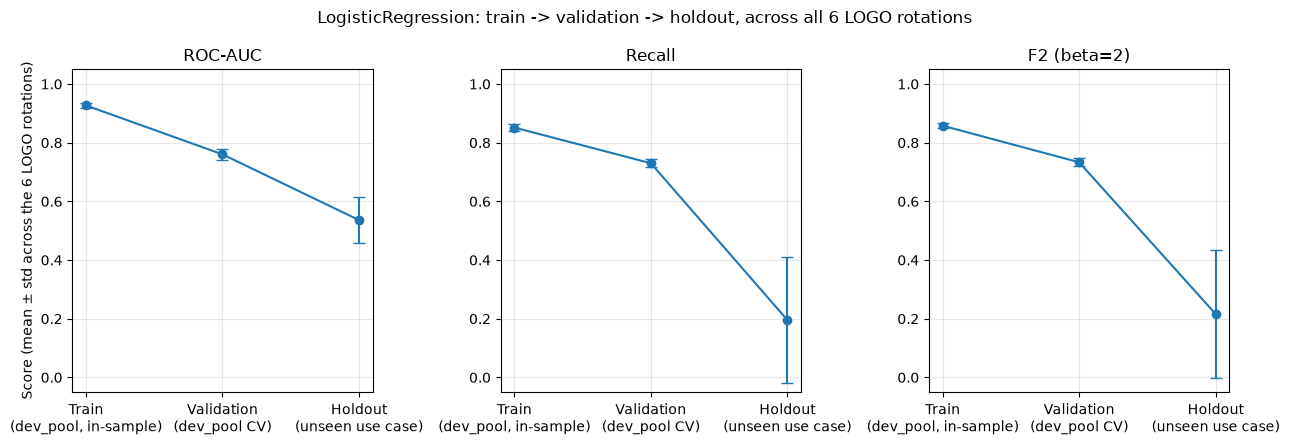

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True)
stage_cols = {
    "ROC-AUC": ("train_auc", "validation_auc", "holdout_auc"),
    "Recall": ("train_recall", "validation_recall", "holdout_recall"),
    "F2 (beta=2)": ("train_f2", "validation_f2", "holdout_f2"),
}
stage_labels = ["Train\n(dev_pool, in-sample)", "Validation\n(dev_pool CV)", "Holdout\n(unseen use case)"]

for ax, (label, (train_col, val_col, hold_col)) in zip(axes, stage_cols.items()):
    means = [logo_results[train_col].mean(), logo_results[val_col].mean(), logo_results[hold_col].mean()]
    stds = [logo_results[train_col].std(), logo_results[val_col].std(), logo_results[hold_col].std()]
    ax.errorbar(range(3), means, yerr=stds, marker="o", capsize=4, color="tab:blue")
    ax.set_xticks(range(3))
    ax.set_xticklabels(stage_labels)
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score (mean \u00b1 std across the 6 LOGO rotations)")
fig.suptitle("LogisticRegression: train -> validation -> holdout, across all 6 LOGO rotations")
plt.tight_layout()
plt.show()


**Hard finding — this reproduces `sf_logo_fold_strategy.ipynb`'s `LogisticRegression`
numbers almost exactly, now derived through the shared, config-driven `Pipeline`
architecture instead of hand-rolled fit/transform calls: mean holdout AUC 0.536 ± 0.078**,
vs. mean validation AUC 0.760 ± 0.018 and mean train AUC 0.927 ± 0.008. The domain-shift
gap (`auc_gap`, validation → holdout, mean 0.224) is again clearly larger than the
overfitting gap (`overfit_gap_auc`, train → validation, mean 0.167) — the same pattern
`sf_logo_fold_strategy.ipynb` §3.2 found across all three model types, now confirmed to
hold for `LogisticRegression` alone when it's the only model in the loop, not just as one
of three being compared.

**Hard finding — Recall collapses far more than AUC, and it collapses unevenly across
rotations.** Mean holdout Recall is 0.196, down from 0.730 in validation — but the
per-rotation table (§4) shows this isn't one uniform drop: `cement_binders` holds up at
0.606 recall, while the other five rotations sit at 0.011–0.238. `cement_binders` is doing
almost all of the work keeping the 6-rotation average off the floor — a single-rotation
holdout that happened to land on it would tell a much rosier story than the other five
rotations support. This is exactly the "n=1 is not a distribution" argument
`sf_logo_fold_strategy.ipynb` was built to make, now visible in Recall too, not just AUC.

**On the leakage check (§2):** zero cross-use-case duplicate titles among the 1,852
reviewed rows this notebook actually trains/evaluates on (the 5 duplicates
`sf_eda_v2.ipynb` §6.2 and `sf_logo_fold_strategy.ipynb` §1 originally flagged all involve
at least one row from the unreviewed/`pass` pool, which `prepare_dataset` drops before this
check ever runs) — a more precise version of that finding, not a contradiction of it: the
risk is real for the full dataset, but doesn't currently touch the specific rows this
pipeline is scored on.


## 6. Checklist — what to change when the real engineered dataset lands

Identical to `sf_generalized_fold_pipeline.ipynb` §6 — both notebooks share `CONFIG`'s
shape and `scripts/fold_pipeline_utils.py`, so the same edits apply to both:

1. Point `CONFIG["data_path"]` at the new file.
2. **Delete §0's "TEMPORARY stand-in" cell entirely.**
3. Add every new engineered column to `CONFIG["numeric_feature_cols"]` or
   `CONFIG["categorical_feature_cols"]` — nothing else needs to change.
4. If the new dataset ships its own grouping key, point `CONFIG["group_col"]` at it
   directly instead of letting `prepare_dataset` derive one.
5. If the embedding column's name or dimensionality changes, only
   `CONFIG["embedding_col"]` needs updating.
6. Re-run from the top; `validate_schema` (§1) fails loudly if anything's still misaligned.
7. **This checklist can't fix upstream leakage:** if the feature-engineering pipeline
   itself fits any statistic (a percentile rank, a global mean/std, a learned encoding) on
   the *full* dataset before handing it here, no split-timing discipline in this notebook
   can undo that — flag it to the feature-engineering track directly. This applies one
   level deeper here than in `sf_generalized_fold_pipeline.ipynb`: a "per-use-case"
   statistic computed across a whole use case's rows *before* this notebook's inner split
   (§4) still leaks across that inner split, even though it can't leak across the outer
   LOGO boundary (a use case is never split between `dev_pool` and its own `holdout`).
